In [1]:
%load_ext autoreload
%autoreload 2

from src.sampling.main import stratified_spatial_kfold_dual

import torch
from torch_geometric.data import Data
from src.raingauge.utils import (
    get_station_coordinate_mappings,
    load_raingauge_dataset,
    get_station_mapping_df,
    filter_uptime
)
import pandas as pd
import numpy as np
import tqdm
import random
import matplotlib.pyplot as plt
import time
import yaml
from scipy.stats import pearsonr
from src.radar.utils import load_radar_dataset
from src.visualization.radar import (
    visualize_one_radar_image,
)
import matplotlib as mpl
from models.gnn import GNNInductive
from datetime import datetime
from src.performance_logger import PerformanceLogger
import os
from src.visualization.inductive_graphs import visualize_splitted_graphs
from src.utils import (
    build_train_and_full_graph_homogeneous,
    add_homogeneous_weather_station_data,
    add_homogeneous_mask_to_data,
    generate_homogeneous_edges,
    add_homogeneous_edge_attributes_to_data,
    prepare_homogeneous_inductive_dataset,
    debug_dataloader,
)

from training.logic import train_epoch, validate, test_model

from src.graph.gaugegraph import GaugeGraph
import networkx as nx
from matplotlib.patches import Patch
import torch.nn.functional as F

/opt/miniconda3/envs/fyp/lib/python3.13/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# NOTE: Geographic extent of Singapore in longitude and latitude
bounds_singapore = {"left": 103.6, "right": 104.1, "top": 1.5, "bottom": 1.188}
bounds = [0.1, 0.2, 0.5, 1, 2, 4, 7, 10, 20]
norm = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=256, extend="both")

experiment_name = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_new"
os.makedirs(f"experiments/{experiment_name}", exist_ok=True)
perf = PerformanceLogger(f"experiments/{experiment_name}/training_log.jsonl")

#Read config file
config_file = 'config.yaml'
with open(config_file) as f:
    config = yaml.safe_load(f)

# Preprocess station data.

1. Load weather station information
2. Load weather station mappings
3. Filter weather stations by uptime

In [3]:
uptime_treshold = config['filters']['uptime_treshold']
start_year = config['dataset_parameters']['start_year']
end_year = config['dataset_parameters']['end_year']
weather_station_df = load_raingauge_dataset(f'database/{config['dataset_parameters']['raingauge_file']}')
weather_station_mappings_df = get_station_mapping_df(start_year, end_year)
weather_station_mappings = get_station_coordinate_mappings("", start = 2021, end = 2025)

Loading raingauge_dataset from database/raingauge_data_2021_2025.csv
Unnamed: 0                            0
timestamp     2021-01-01T00:00:00+08:00
stationId                           S91
value                               0.0
Name: 0, dtype: object
Loading complete
Dataframe shape: (521999, 80)


In [4]:
#optional: get rid of excess no rain event
weather_station_filtered_cols = filter_uptime(weather_station_df).index
weather_station_filtered_df = weather_station_df[weather_station_filtered_cols]
# weather_station_filtered_df = weather_station_df.fillna(0)
# weather_station_filtered_df = (weather_station_filtered_df != 0).sum(axis=1)
# has_rain = weather_station_filtered_df > 0
# window_size = pd.Timedelta(hours=3)

# rain_indices = weather_station_df.index[has_rain]
# keep_mask = pd.Series(False, index=weather_station_df.index)

# for rain_time in rain_indices:
#     # Mark all timestamps within 3 hours before and after as "keep"
#     mask = (weather_station_df.index >= rain_time - window_size) & \
#            (weather_station_df.index <= rain_time + window_size)
#     keep_mask = keep_mask | mask

# weather_station_df = weather_station_df[keep_mask]

#_________


rainfall_stations = weather_station_filtered_df.columns
general_station = []

# 3.1 Also filter weather station mappings
weather_station_mappings = {k: v for k, v in weather_station_mappings.items() if k in rainfall_stations}
print("________")

weather_station_df = weather_station_df.resample("15min").first()
weather_station_df.fillna(0, inplace=True)

print("--- Station Data Stats ---")
print(weather_station_df.describe())

________
--- Station Data Stats ---
stationId            S06            S07            S08           S100  \
count      175296.000000  175296.000000  175296.000000  175296.000000   
mean            0.039472       0.175329       0.352204       0.153423   
std             1.167042       2.455823       3.679776       2.247924   
min             0.000000       0.000000       0.000000       0.000000   
25%             0.000000       0.000000       0.000000       0.000000   
50%             0.000000       0.000000       0.000000       0.000000   
75%             0.000000       0.000000       0.000000       0.000000   
max           163.200000     180.000000     165.600000     136.800000   

stationId           S102           S104           S106           S107  \
count      175296.000000  175296.000000  175296.000000  175296.000000   
mean            0.049918       0.292662       0.216197       0.269838   
std             1.174880       3.174959       2.663973       3.338814   
min           

## Get list of station_ids

In [5]:
general_station_data = {}
rainfall_station_data = {}
dtype = torch.float32
fold_count = 5

# Prepare features in the correct order
general_station_features = []
rainfall_station_features = []
general_station_order = []
rainfall_station_order = [] # IMPORTANT TO KEEP TRACK OF ORDERING

for station in rainfall_stations:
    station_feat = weather_station_df[station]
    rainfall_station_features.append(station_feat)
    rainfall_station_order.append(station)


# Stratified K Fold Spatial Sampling

In [6]:
split_info = stratified_spatial_kfold_dual(
    weather_station_mappings, seed=123, plot=False, n_splits = fold_count
)
print(split_info)

SPATIAL K-FOLD STRATIFIED SAMPLING (Fixed)
Total stations: 50
Clusters: 8
Folds: 5
Random seed: 123
--------------------------------------------------------------------------------
Cluster 0: 8 stations → 5 test assignments, 3 always-train
Cluster 1: 5 stations → 5 test assignments, 0 always-train
Cluster 2: 6 stations → 5 test assignments, 1 always-train
Cluster 3: 7 stations → 5 test assignments, 2 always-train
Cluster 4: 5 stations → 5 test assignments, 0 always-train
Cluster 5: 6 stations → 5 test assignments, 1 always-train
Cluster 6: 8 stations → 5 test assignments, 3 always-train
Cluster 7: 5 stations → 5 test assignments, 0 always-train

Creating Fold 1/5
Test stations: 8 (should be ~8)
Train pool: 42
Fold 1 summary:
  Statistical train: 42 (84.0%)
  Test: 8 (16.0%)
  ML train: 34 (68.0%)
  ML validation: 8 (16.0%)

Creating Fold 2/5
Test stations: 8 (should be ~8)
Train pool: 42
Fold 2 summary:
  Statistical train: 42 (84.0%)
  Test: 8 (16.0%)
  ML train: 34 (68.0%)
  ML valid

## Add Station Features to HeteroData Class
Note: Currently we are only using rainfall values so there is no need for general stations

/var/folders/h7/zmlpvml96rn3fnlg2qxg2nt80000gn/T/ipykernel_63255/2953259414.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rainfall_station_data_tensor = torch.tensor(rainfall_station_features)


HERE
Data(x=[175296, 50], y=[175296, 50], station_id=[50])

=== Station Features Added ===
Station features shape: torch.Size([175296, 50])
Data(x=[175296, 50, 1], y=[175296, 50, 1], station_id=[50], train_mask=[50], val_mask=[50], test_mask=[50])
Data(x=[175296, 50, 1], y=[175296, 50, 1], station_id=[50], train_mask=[50], val_mask=[50], test_mask=[50])
SPLIT DATA

Total stations for KNN: 34
['S08' 'S104' 'S107' 'S109' 'S111' 'S112' 'S115' 'S119' 'S123' 'S201'
 'S209' 'S210' 'S213' 'S214' 'S215' 'S216' 'S219' 'S222' 'S223' 'S224'
 'S228' 'S230' 'S33' 'S40' 'S43' 'S50' 'S66' 'S78' 'S79' 'S81' 'S84' 'S88'
 'S90' 'S94']
[[  1.3701  103.8271 ]
 [  1.44387 103.78538]
 [  1.3135  103.9625 ]
 [  1.3764  103.8492 ]
 [  1.31055 103.8365 ]
 [  1.43854 103.70131]
 [  1.29377 103.61843]
 [  1.30105 103.8666 ]
 [  1.3214  103.8577 ]
 [  1.32311 103.76714]
 [  1.42111 103.84472]
 [  1.44003 103.76904]
 [  1.32427 103.8097 ]
 [  1.29911 103.88289]
 [  1.32785 103.88899]
 [  1.36019 103.85335]
 [  1.3

/Users/jylow/Documents/FYP/rainfall_data_fusion/src/graph/gaugegraph.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.bool)
/Users/jylow/Documents/FYP/rainfall_data_fusion/src/graph/gaugegraph.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.bool)
/Users/jylow/Documents/FYP/rainfall_data_fusion/src/graph/gaugegraph.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.bool)
/Users/jylow/Documents/FYP/rainfall_data_fusio

Data(x=[175296, 50], y=[175296, 50], station_id=[50])

=== Station Features Added ===
Station features shape: torch.Size([175296, 50])
Data(x=[175296, 50, 1], y=[175296, 50, 1], station_id=[50], train_mask=[50], val_mask=[50], test_mask=[50])
Data(x=[175296, 50, 1], y=[175296, 50, 1], station_id=[50], train_mask=[50], val_mask=[50], test_mask=[50])
SPLIT DATA

Total stations for KNN: 34
['S08' 'S107' 'S111' 'S112' 'S113' 'S115' 'S119' 'S123' 'S201' 'S211'
 'S213' 'S214' 'S215' 'S216' 'S219' 'S220' 'S221' 'S223' 'S224' 'S227'
 'S228' 'S230' 'S24' 'S40' 'S44' 'S66' 'S69' 'S71' 'S77' 'S79' 'S88' 'S90'
 'S900' 'S94']
[[  1.3701  103.8271 ]
 [  1.3135  103.9625 ]
 [  1.31055 103.8365 ]
 [  1.43854 103.70131]
 [  1.30648 103.9104 ]
 [  1.29377 103.61843]
 [  1.30105 103.8666 ]
 [  1.3214  103.8577 ]
 [  1.32311 103.76714]
 [  1.42918 103.75711]
 [  1.32427 103.8097 ]
 [  1.29911 103.88289]
 [  1.32785 103.88899]
 [  1.36019 103.85335]
 [  1.37999 103.87643]
 [  1.38666 103.89797]
 [  1.35691

/Users/jylow/Documents/FYP/rainfall_data_fusion/src/graph/gaugegraph.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.bool)
/Users/jylow/Documents/FYP/rainfall_data_fusion/src/graph/gaugegraph.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.bool)
/Users/jylow/Documents/FYP/rainfall_data_fusion/src/graph/gaugegraph.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.bool)
/Users/jylow/Documents/FYP/rainfall_data_fusio

Data(x=[175296, 50], y=[175296, 50], station_id=[50])

=== Station Features Added ===
Station features shape: torch.Size([175296, 50])
Data(x=[175296, 50, 1], y=[175296, 50, 1], station_id=[50], train_mask=[50], val_mask=[50], test_mask=[50])
Data(x=[175296, 50, 1], y=[175296, 50, 1], station_id=[50], train_mask=[50], val_mask=[50], test_mask=[50])
SPLIT DATA

Total stations for KNN: 34
['S08' 'S104' 'S109' 'S111' 'S112' 'S113' 'S119' 'S123' 'S201' 'S211'
 'S215' 'S216' 'S217' 'S219' 'S222' 'S224' 'S226' 'S229' 'S24' 'S33' 'S40'
 'S43' 'S44' 'S50' 'S66' 'S71' 'S77' 'S78' 'S79' 'S81' 'S84' 'S90' 'S900'
 'S94']
[[  1.3701  103.8271 ]
 [  1.44387 103.78538]
 [  1.3764  103.8492 ]
 [  1.31055 103.8365 ]
 [  1.43854 103.70131]
 [  1.30648 103.9104 ]
 [  1.30105 103.8666 ]
 [  1.3214  103.8577 ]
 [  1.32311 103.76714]
 [  1.42918 103.75711]
 [  1.32785 103.88899]
 [  1.36019 103.85335]
 [  1.35041 103.85526]
 [  1.37999 103.87643]
 [  1.28987 103.82364]
 [  1.34392 103.98409]
 [  1.27472 103

/Users/jylow/Documents/FYP/rainfall_data_fusion/src/graph/gaugegraph.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.bool)
/Users/jylow/Documents/FYP/rainfall_data_fusion/src/graph/gaugegraph.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.bool)


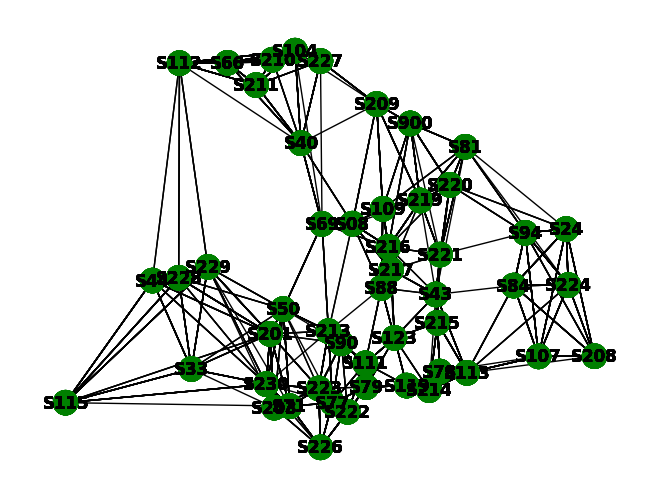

In [7]:
rainfall_station_data_tensor = torch.tensor(rainfall_station_features)
gauge_graph_arr = []
for i in range(fold_count):
  data = add_homogeneous_weather_station_data(
        Data(), # empty pygeometric Data type
        general_station_features = None,
        rainfall_station_features=rainfall_station_data_tensor,
        general_station_ids = None,
        rainfall_station_ids = rainfall_station_order,
        dtype=dtype,
    )
  
  data = add_homogeneous_mask_to_data(data, split_info[i], rainfall_stations)
  data.x = data.x.unsqueeze(-1)
  data.y = data.y.unsqueeze(-1)
  print(data)
  gauge_graph_arr.append(GaugeGraph(
    data = data,
    station_dict=weather_station_mappings,
    split_info=split_info[i],
    raingauge_station_order = rainfall_station_order,
    knn = 4
  ))

  



In [ ]:
gauge_graph_arr[0].visualise_graph_split()

##

## Graph Generation
We will generate the following graphs.
1. Training graph: Train Nodes
2. Validation graph: Train + Val nodes
3. Testing graph: Train + Val + Test Nodes

The graphs will be generated independently. 
Each graph will be connected with the K nearest neighbours where K = 4 such that the graph will be fully connected.

Note: Future graph creations with methods like epsilon ball radius and fully connected graphs can also be explored

# Creating the GNN

In [8]:
hidden_channels = 4
in_channels = 1
out_channels = 1
num_layers = 4
model_arr = []
device = "cuda" if torch.cuda.is_available() else "cpu"

for i in range(fold_count):
    model_arr.append(
        GNNInductive(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            num_layers=num_layers,
        ).to(device=device)
    )

## Training logic

In [ ]:
gauge_graph_arr[0].get_train_graph().station_id

In [ ]:
gauge_graph_arr[0].get_validation_graph()

In [9]:
# set seeds

seed = 123
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
perf.log_model_config(model_arr[0].config)

batch_size = 16
train_loader_arr = []
val_loader_arr = []
for i in range(fold_count):
    gauge_graph = gauge_graph_arr[i]
    train_loader, val_loader = prepare_homogeneous_inductive_dataset(
        gauge_graph.get_train_graph(), gauge_graph.get_validation_graph(), batch_size=batch_size, mode="train"
    )
    train_loader_arr.append(train_loader)
    val_loader_arr.append(val_loader)


def train(model, train_loader, val_loader, fold, device="cpu"):
    # CHECK 1: Print initial weights
    first_param = next(model.parameters())
    print(f"Initial weight sample: {first_param.data.flatten()[:5]}")

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    training_loss_arr = []
    validation_loss_arr = []
    early = 0
    mini = 1000
    stopping_condition = 5
    epochs = 0
    total_epochs = 10
    print(f"-----FOLD: {fold}-----")
    training_start = time.time()
    for i in range(total_epochs):
        print(f"-----EPOCH: {i + 1}-----")

        # CHECK 2: Print weight before training
        weight_before = first_param.data.clone()

        train_loss = train_epoch(
            model,
            train_loader,
            optimizer,
            device,
            verbose=False,
            random_noise_masking=False,
        )

        # CHECK 3: Print weight after training
        weight_after = first_param.data
        weight_change = (weight_after - weight_before).abs().mean().item()
        print(f"Weight change: {weight_change:.20f}")

        validation_loss = validate(model, val_loader, device)
        training_loss_arr.append(train_loss)
        validation_loss_arr.append(validation_loss)
        perf.log_epoch(i, train_loss, validation_loss)
        if mini >= validation_loss:
            mini = validation_loss
            early = 0
        else:
            early += 1
        epochs += 1
        if early >= stopping_condition:
            print("Early stop loss")
            break

        print(f"Train Loss: {train_loss:.4f}")
        print(f"Validation Loss: {validation_loss:.4f}")

        # CHECK 4: Print gradient norms
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm**0.5
        print(f"Gradient norm: {total_norm:.6f}")

    training_end = time.time()
    total_time = training_end - training_start
    perf.finalise(total_time)

    print(f"Training took {total_time} seconds over {epochs} epochs")
    plt.plot(training_loss_arr, label="training_loss", color="blue")
    plt.plot(validation_loss_arr, label="validation_loss", color="red")
    plt.legend()
    plt.savefig(f"experiments/{experiment_name}/train_loss_plot_{fold}.png", dpi=300)
    plt.close()

    torch.save(
        model.state_dict(), f"experiments/{experiment_name}/weather_gnn_best_{fold}.pth"
    )
    print("✅ model weights saved to weather_gnn_best.pth")

    perf.log_model_parameters(model)
    return model


for i in range(fold_count):
    model = train(model_arr[i], train_loader_arr[i], val_loader_arr[i], fold=i, device=device)



PREPARING TRAIN/VAL DATALOADERS (using train_graph)
Data(x=[34, 1], edge_index=[2, 136], edge_attr=[1, 136], y=[34, 1], mask=[50], train_mask=[50], station_id=[50], num_nodes=34)
Sample node features shape: torch.Size([34, 1])
Sample labels shape: torch.Size([34, 1])
Train mask shape: torch.Size([50])
Train mask sum (trainable nodes): 34
✅ Train loader: 10956 batches
✅ Val loader: 10956 batches
torch.Size([1])

BATCH VERIFICATION
Batch content: DataBatch(x=[544, 1], edge_index=[2, 2176], edge_attr=[16, 136], y=[544, 1], mask=[800], train_mask=[800], station_id=[800], num_nodes=544, batch=[544], ptr=[17])
Batched x shape: torch.Size([544, 1])
Batched y shape: torch.Size([544, 1])
Mask shape: torch.Size([800])
Edge index shape: torch.Size([2, 2176])
Batch vector shape: torch.Size([544])
Num graphs in batch: 16

Nodes per graph: 34
Mask size per graph: 50
❌ MISMATCH!

PREPARING TRAIN/VAL DATALOADERS (using train_graph)
Data(x=[34, 1], edge_index=[2, 136], edge_attr=[1, 136], y=[34, 1], m

training:   3%|▎         | 366/10956 [00:10<05:03, 34.85it/s, loss=0.00582] 


KeyboardInterrupt: 

In [ ]:
sids = gauge_graph_arr[0].get_test_graph().station_id
print(sids)
masked_ids = sids[gauge_graph_arr[0].get_test_graph().test_mask]
masked_ids

In [ ]:
test_loader_arr = []
for i in range(fold_count):
    gauge_graph = gauge_graph_arr[i]
    test_loader = prepare_homogeneous_inductive_dataset(
        gauge_graph.get_train_graph(),
        gauge_graph.get_validation_graph(),
        gauge_graph.get_test_graph(),
        batch_size=batch_size,
        mode="test",
    )
    test_loader_arr.append(test_loader)

for i in range(fold_count):
    RMSE = test_model(model_arr[i], test_loader_arr[i], device, fold=i, experiment_name=experiment_name)
    print(f"TEST RMSE: {RMSE}")